In [373]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


slp = pd.read_sas('.data/raw/P_SLQ.xpt')
demo = pd.read_sas('.data/raw/P_DEMO.xpt')
bmx  = pd.read_sas('.data/raw/P_BMX.xpt')
alq  = pd.read_sas('.data/raw/P_ALQ.xpt')
paq  = pd.read_sas('.data/raw/P_PAQ.xpt')
bpc = pd.read_sas('.data/raw/P_BPQ.xpt')
inc = pd.read_sas('.data/raw/P_INQ.xpt')
dbq= pd.read_sas('.data/raw/P_DBQ.xpt')
dr= pd.read_sas('.data/raw/P_DR1TOT.xpt')

print(alq)

          SEQN  ALQ111        ALQ121  ALQ130        ALQ142        ALQ270  \
0     109266.0     1.0  1.000000e+01     1.0  5.397605e-79           NaN   
1     109271.0     1.0  5.397605e-79     NaN           NaN           NaN   
2     109273.0     1.0  5.397605e-79     NaN           NaN           NaN   
3     109274.0     1.0  4.000000e+00     2.0  5.000000e+00  7.000000e+00   
4     109282.0     1.0  5.397605e-79     NaN           NaN           NaN   
...        ...     ...           ...     ...           ...           ...   
8960  124815.0     1.0  3.000000e+00     1.0  5.397605e-79           NaN   
8961  124817.0     1.0  3.000000e+00     2.0  5.397605e-79           NaN   
8962  124818.0     1.0  9.000000e+00     2.0  5.397605e-79           NaN   
8963  124821.0     1.0  5.000000e+00     5.0  7.000000e+00  5.397605e-79   
8964  124822.0     1.0  6.000000e+00     2.0  5.397605e-79           NaN   

            ALQ280  ALQ290  ALQ151        ALQ170  
0              NaN     NaN     2.0  

In [374]:
df = demo.merge(bmx, on="SEQN", how="inner") \
         .merge(alq, on="SEQN", how="inner") \
         .merge(paq, on="SEQN", how="inner") \
            .merge(slp, on="SEQN", how="inner")\
            .merge(bpc, on="SEQN", how="inner")\
            .merge(inc, on="SEQN", how="inner")\
            .merge(dbq,on="SEQN", how="inner")\
            .merge(dr,on="SEQN", how="inner")

In [375]:
df.head(5)

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,...,DRD370QQ,DRD370R,DRD370RQ,DRD370S,DRD370SQ,DRD370T,DRD370TQ,DRD370U,DRD370UQ,DRD370V
0,109266.0,66.0,2.0,2.0,29.0,NaN,5.0,6.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109271.0,66.0,2.0,1.0,49.0,NaN,3.0,3.0,2.0,1.0,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0
2,109273.0,66.0,2.0,1.0,36.0,NaN,3.0,3.0,2.0,1.0,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0
3,109274.0,66.0,2.0,1.0,68.0,NaN,5.0,7.0,1.0,1.0,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,2.0
4,109282.0,66.0,2.0,1.0,76.0,NaN,3.0,3.0,2.0,1.0,...,NaN,2.0,NaN,2.0,NaN,1.0,2.0,2.0,NaN,2.0


In [376]:
df = df[
[
"SEQN",
"RIDAGEYR",
"RIAGENDR",
"BMXBMI",
"ALQ111",
"ALQ130",
"PAQ605",
"PAQ620",
"SLD012",
"INDFMMPI",
"BPQ020",
"DR1TKCAL",
"DR1TSUGR",
"DR1TTFAT",
"DR1TPROT",
"DR1TSODI",
"DBD895",
"DBD900"
]
]

In [377]:
df = df.replace(5.397605e-79, np.nan)

In [378]:
df.head(5)

,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,ALQ111,ALQ130,PAQ605,PAQ620,SLD012,INDFMMPI,BPQ020,DR1TKCAL,DR1TSUGR,DR1TTFAT,DR1TPROT,DR1TSODI,DBD895,DBD900
0,109266.0,29.0,2.0,37.8,1.0,1.0,2.0,2.0,7.5,5.00,2.0,1698.0,94.20,73.81,52.58,2001.0,7.000000e+00,5.397605e-79
1,109271.0,49.0,1.0,29.7,1.0,NaN,2.0,1.0,10.0,1.20,2.0,2310.0,85.00,113.77,110.62,5446.0,2.000000e+00,2.000000e+00
2,109273.0,36.0,1.0,21.9,1.0,NaN,1.0,2.0,6.5,0.53,2.0,1403.0,162.78,13.70,56.73,1990.0,2.000000e+00,2.000000e+00
3,109274.0,68.0,1.0,30.2,1.0,2.0,1.0,1.0,9.5,1.20,1.0,2385.0,60.84,86.42,77.75,6717.0,5.397605e-79,NaN
4,109282.0,76.0,1.0,26.6,1.0,NaN,2.0,2.0,7.0,3.18,1.0,2026.0,139.16,64.05,58.33,2456.0,1.000000e+00,1.000000e+00


In [379]:
df.isnull().sum()

SEQN           0
RIDAGEYR       0
RIAGENDR       0
BMXBMI       175
ALQ111       595
ALQ130      3102
PAQ605         0
PAQ620         0
SLD012        79
INDFMMPI    1904
BPQ020         0
DR1TKCAL     873
DR1TSUGR     873
DR1TTFAT     873
DR1TPROT     873
DR1TSODI     873
DBD895         0
DBD900      1896
dtype: int64

In [380]:
#handling missing values.
for col in ['DR1TKCAL','DR1TSUGR','DR1TTFAT','DR1TPROT','DR1TSODI']:
    df[col + '_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())
df['DBD900_missing'] = df['DBD900'].isna().astype(int)
df['DBD900'] = df['DBD900'].fillna(0)
df["ALQ111"] = df["ALQ111"].fillna(3) # Assuming unknown drinking as 3 which is other category. 
df["SLD012"] = df["SLD012"].fillna(df["SLD012"].median())
df["INDFMMPI"] = df["INDFMMPI"].fillna(df["INDFMMPI"].mean()) # Assuming mean for continuous variable.

In [381]:
#drop rows with bmi missing values, because we cannot calculate the target variable without it
df = df.dropna(subset=["BMXBMI"])

In [382]:
#dropping ALQ130 because it has too many missing values
df = df.drop(columns=["ALQ130"])

In [383]:
#create target variable and drop BMI column to avoid data leakage
df["Obese"] = df["BMXBMI"].apply(lambda x: 1 if x >= 30 else 0)
df = df.drop(columns=["BMXBMI"])

In [384]:
df.head(5)

,SEQN,RIDAGEYR,RIAGENDR,ALQ111,PAQ605,PAQ620,SLD012,INDFMMPI,BPQ020,DR1TKCAL,...,DR1TSODI,DBD895,DBD900,DR1TKCAL_missing,DR1TSUGR_missing,DR1TTFAT_missing,DR1TPROT_missing,DR1TSODI_missing,DBD900_missing,Obese
0,109266.0,29.0,2.0,1.0,2.0,2.0,7.5,5.00,2.0,1698.0,...,2001.0,7.000000e+00,5.397605e-79,0,0,0,0,0,0,1
1,109271.0,49.0,1.0,1.0,2.0,1.0,10.0,1.20,2.0,2310.0,...,5446.0,2.000000e+00,2.000000e+00,0,0,0,0,0,0,0
2,109273.0,36.0,1.0,1.0,1.0,2.0,6.5,0.53,2.0,1403.0,...,1990.0,2.000000e+00,2.000000e+00,0,0,0,0,0,0,0
3,109274.0,68.0,1.0,1.0,1.0,1.0,9.5,1.20,1.0,2385.0,...,6717.0,5.397605e-79,0.000000e+00,0,0,0,0,0,1,1
4,109282.0,76.0,1.0,1.0,2.0,2.0,7.0,3.18,1.0,2026.0,...,2456.0,1.000000e+00,1.000000e+00,0,0,0,0,0,0,0


In [385]:
# gender
df["RIAGENDR"] = df["RIAGENDR"].map({1: 0, 2: 1})

# alcohol
df["ALQ111"] = (df["ALQ111"] == 1).astype(int)

# BP
df["BPQ020"] = (df["BPQ020"] == 1).astype(int)

In [386]:
df['protein_ratio'] = df['DR1TPROT'] / df['DR1TKCAL']
df['sugar_ratio'] = df['DR1TSUGR'] / df['DR1TKCAL']
df['sodium_density'] = df['DR1TSODI'] / df['DR1TKCAL']
df['fast_food_ratio'] = df['DBD900'] / (df['DBD895'] + 1)
df['calorie_activity'] = df['DR1TKCAL'] * df['PAQ605']
df['fat_calorie_ratio'] = df['DR1TTFAT'] / df['DR1TKCAL']
df['diet_quality'] = df['protein_ratio'] - df['sugar_ratio']

In [387]:
X = df.drop(columns=["SEQN", "Obese", "PAQ605", "DR1TSODI","SEQN","ALQ111","DR1TKCAL_missing",
    "DR1TSUGR_missing",
    "DR1TTFAT_missing",
    "DR1TPROT_missing",
    "DR1TSODI_missing","diet_quality",      # derived from ratios → remove
    "DR1TPROT",          # raw → redundant
    "DR1TSUGR",          # raw → redundant
    "DR1TTFAT","DR1TKCAL"]) # raw → redundant
y = df["Obese"]

In [388]:
X.columns

Index(['RIDAGEYR', 'RIAGENDR', 'PAQ620', 'SLD012', 'INDFMMPI', 'BPQ020',
       'DBD895', 'DBD900', 'DBD900_missing', 'protein_ratio', 'sugar_ratio',
       'sodium_density', 'fast_food_ratio', 'calorie_activity',
       'fat_calorie_ratio'],
      dtype='str')

In [389]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [390]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [391]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [392]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6131968145620023

               precision    recall  f1-score   support

           0       0.63      0.81      0.71      1008
           1       0.58      0.35      0.44       750

    accuracy                           0.61      1758
   macro avg       0.60      0.58      0.57      1758
weighted avg       0.60      0.61      0.59      1758


Confusion Matrix:
 [[814 194]
 [486 264]]


In [393]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=X.columns)
print(importance.sort_values(ascending=False))

BPQ020               0.410298
fast_food_ratio      0.246523
fat_calorie_ratio    0.161610
RIAGENDR             0.153071
sodium_density       0.088086
sugar_ratio          0.012528
calorie_activity    -0.003060
DBD895              -0.013704
protein_ratio       -0.068312
INDFMMPI            -0.080402
RIDAGEYR            -0.088295
PAQ620              -0.088437
SLD012              -0.099478
DBD900_missing      -0.143437
DBD900              -0.249895
dtype: float64


In [394]:
# ! IMPORTANT: Run all cells above this point first (cells 1-20) before running Phase 1A optimization
# This ensures all required variables (X, y, X_train, X_test, y_train, y_test, model, scaler) are initialized

# Verify all required variables exist
required_vars = ['X', 'y', 'X_train', 'X_test', 'y_train', 'y_test', 'model', 'scaler']
missing_vars = [var for var in required_vars if var not in locals()]

if missing_vars:
    print(f"❌ ERROR: Missing variables: {missing_vars}")
    print(f"Please execute ALL cells above (cells 1-20) before running Phase 1A optimization")
    print("\nTo run all cells: Click 'Run All' button or press Ctrl+Alt+Shift+Enter")
else:
    print("✓ All required variables are available")
    print(f"✓ Ready to proceed with Phase 1A optimization")
    print(f"✓ Dataset shape: {X.shape}")
    print(f"✓ Test set size: {len(X_test)}")

✓ All required variables are available
✓ Ready to proceed with Phase 1A optimization
✓ Dataset shape: (8790, 15)
✓ Test set size: 1758


# Phase 1A: Model Optimization
## Advanced Feature Analysis & Hyperparameter Tuning

### Prerequisites
Make sure you have executed ALL cells (1-20) above before running this section. These cells prepare the data and train the baseline model.

1. FEATURE CORRELATION ANALYSIS

Pearson Correlation Matrix:
                   RIDAGEYR  RIAGENDR    PAQ620    SLD012  INDFMMPI    BPQ020  \
RIDAGEYR           1.000000 -0.019044  0.122348  0.016088  0.085457  0.441872   
RIAGENDR          -0.019044  1.000000  0.093861  0.069322 -0.046306 -0.008753   
PAQ620             0.122348  0.093861  1.000000  0.065674  0.001668  0.036229   
SLD012             0.016088  0.069322  0.065674  1.000000 -0.040996 -0.003738   
INDFMMPI           0.085457 -0.046306  0.001668 -0.040996  1.000000 -0.007362   
BPQ020             0.441872 -0.008753  0.036229 -0.003738 -0.007362  1.000000   
DBD895            -0.030371 -0.006682 -0.002885 -0.012131 -0.007052 -0.018467   
DBD900            -0.013593 -0.004244 -0.023150  0.000159 -0.015014 -0.016626   
DBD900_missing     0.181535  0.029283  0.105274  0.018999 -0.126126  0.062624   
protein_ratio     -0.002372 -0.027146  0.001796 -0.001212  0.023888 -0.004832   
sugar_ratio        0.000255  0.063027 -0.023161 

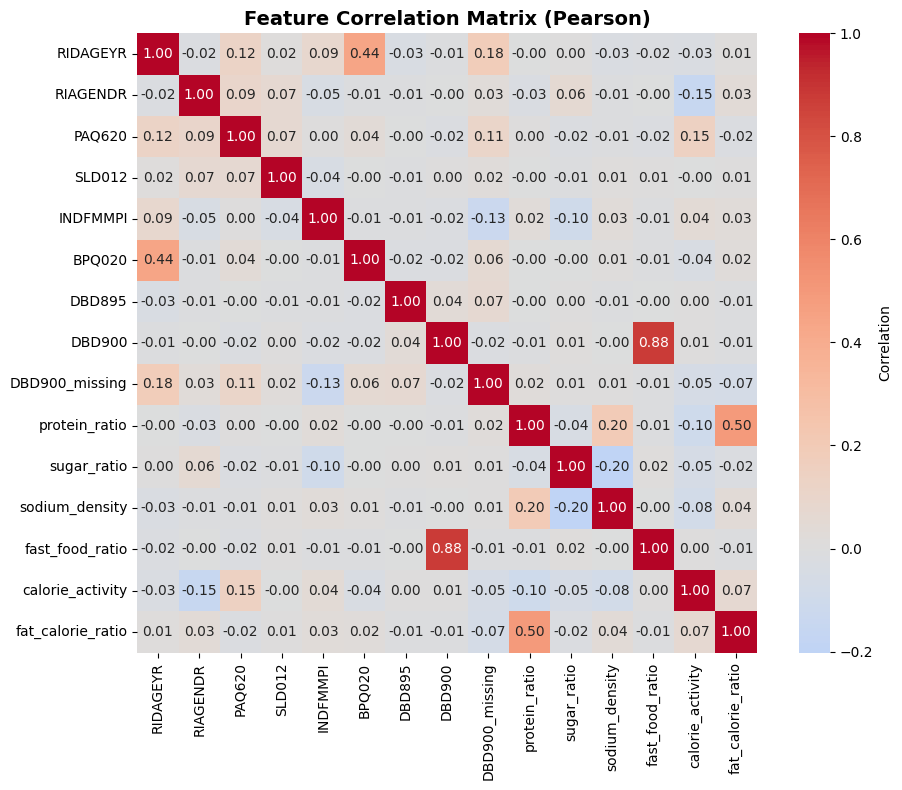

In [395]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Make sure X is available as DataFrame (not numpy array)
if isinstance(X, np.ndarray):
    print("Warning: X is a numpy array, cannot compute correlation. Please re-run cells 1-20.")
else:
    # 1. CORRELATION ANALYSIS
    print("="*70)
    print("1. FEATURE CORRELATION ANALYSIS")
    print("="*70)

    # Correlation matrix using Pearson correlation (use original X, not scaled X_train)
    correlation_matrix = X.corr(method='pearson')
    print("\nPearson Correlation Matrix:")
    print(correlation_matrix)

    # Identify highly correlated pairs (> 0.7 or < -0.7)
    print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
    highly_correlated_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                pair = (correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j])
                highly_correlated_pairs.append(pair)
                print(f"{pair[0]:15} <-> {pair[1]:15} : {pair[2]:.4f}")

    if not highly_correlated_pairs:
        print("No highly correlated pairs found (all |r| ≤ 0.7)")

    # Visualize correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
    plt.title('Feature Correlation Matrix (Pearson)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


2. MULTICOLLINEARITY ANALYSIS - VARIANCE INFLATION FACTOR (VIF)

VIF Scores (VIF > 10 indicates high multicollinearity):
          Feature       VIF
           SLD012 14.825763
fat_calorie_ratio 11.621097
         RIDAGEYR 10.002521
           PAQ620  9.479750
    protein_ratio  9.105089
 calorie_activity  4.882725
   sodium_density  4.524945
           DBD900  4.364770
  fast_food_ratio  4.354916
      sugar_ratio  4.180118
         INDFMMPI  3.901018
         RIAGENDR  2.158285
           BPQ020  1.972825
   DBD900_missing  1.366258
           DBD895  1.017186


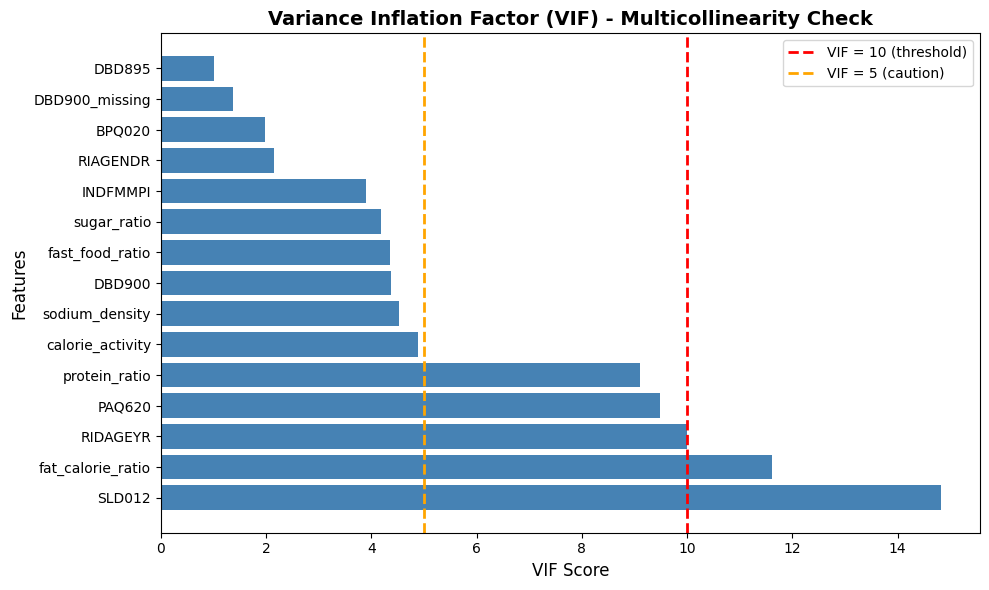


VIF Interpretation:
  VIF = 1: No correlation
  VIF < 5: Generally acceptable
  VIF 5-10: Moderate multicollinearity (caution)
  VIF > 10: High multicollinearity (problematic)


In [396]:
# 2. VARIANCE INFLATION FACTOR (VIF) ANALYSIS
print("\n" + "="*70)
print("2. MULTICOLLINEARITY ANALYSIS - VARIANCE INFLATION FACTOR (VIF)")
print("="*70)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVIF Scores (VIF > 10 indicates high multicollinearity):")
print(vif_data.to_string(index=False))

# Visualize VIF
plt.figure(figsize=(10, 6))
bars = plt.barh(vif_data['Feature'], vif_data['VIF'], color='steelblue')
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='VIF = 10 (threshold)')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='VIF = 5 (caution)')
plt.xlabel('VIF Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Variance Inflation Factor (VIF) - Multicollinearity Check', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("\nVIF Interpretation:")
print("  VIF = 1: No correlation")
print("  VIF < 5: Generally acceptable")
print("  VIF 5-10: Moderate multicollinearity (caution)")
print("  VIF > 10: High multicollinearity (problematic)")

In [397]:
print("\n" + "="*70)
print("3. HYPERPARAMETER TUNING - GRID SEARCH CV (UPDATED)")
print("="*70)

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# ⚠️ SAVE BASELINE PREDICTIONS BEFORE GRID SEARCH
# (Grid search will create a new model and overwrite the 'model' variable)
# The baseline model was already trained in a previous cell, so we just capture its predictions
print("\n➤ Saving baseline model predictions...")
baseline_y_pred = model.predict(X_test)
baseline_y_pred_proba = model.predict_proba(X_test)[:, 1]
print("✓ Baseline predictions saved\n")

# ✅ Updated parameter grid (no deprecated penalty)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['saga'],              # single, powerful solver
    'l1_ratio': [0, 0.5, 1],          # 0=L2, 1=L1, 0.5=ElasticNet
    'max_iter': [2000],
    'class_weight': [None, 'balanced']
}

total_combinations = (
    len(param_grid['C']) *
    len(param_grid['solver']) *
    len(param_grid['l1_ratio']) *
    len(param_grid['max_iter']) *
    len(param_grid['class_weight'])
)

print(f"Performing Grid Search with {total_combinations} parameter combinations...")
print("This will be faster and more meaningful than before...\n")

# ✅ Important: use penalty='elasticnet'
base_model = LogisticRegression(
    random_state=42,
    penalty='elasticnet'
)

grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n{'='*70}")
print("GRID SEARCH RESULTS")
print(f"{'='*70}")
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")

# Top results
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)

top_results = cv_results.nlargest(10, 'mean_test_score')[
    ['param_C', 'param_l1_ratio', 'param_class_weight',
     'mean_test_score', 'std_test_score']
]

print("\nTop 10 Parameter Combinations:")
print(top_results.to_string(index=False))


3. HYPERPARAMETER TUNING - GRID SEARCH CV (UPDATED)

➤ Saving baseline model predictions...
✓ Baseline predictions saved

Performing Grid Search with 30 parameter combinations...
This will be faster and more meaningful than before...

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/anvithaenaganti/Desktop/Capstone_Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/anvithaenaganti/Desktop/Capstone_Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/anvithaenaganti/Desktop/Capstone_Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: Fut


GRID SEARCH RESULTS

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 1, 'max_iter': 2000, 'solver': 'saga'}
Best Cross-Validation ROC-AUC Score: 0.6260

Top 10 Parameter Combinations:
 param_C  param_l1_ratio param_class_weight  mean_test_score  std_test_score
    0.10             1.0           balanced         0.625992        0.022451
    0.10             0.5           balanced         0.625846        0.022537
    0.01             0.0           balanced         0.625772        0.022870
    1.00             1.0           balanced         0.625716        0.022582
    1.00             0.5           balanced         0.625675        0.022512
   10.00             1.0           balanced         0.625655        0.022485
  100.00             0.5           balanced         0.625653        0.022479
  100.00             0.0           balanced         0.625653        0.022479
   10.00             0.0           balanced         0.625653        0.022476
  100.00             1.0 

/Users/anvithaenaganti/Desktop/Capstone_Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/anvithaenaganti/Desktop/Capstone_Project/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [398]:
# 4. BEST MODEL FROM GRID SEARCH
optimized_model = grid_search.best_estimator_

# Predictions with optimized model
y_pred_optimized = optimized_model.predict(X_test)
y_pred_proba_optimized = optimized_model.predict_proba(X_test)[:, 1]

# Use saved baseline predictions (from before grid search)
# y_pred_proba_original and baseline_y_pred were saved in cell 3

print(f"\n{'='*70}")
print("MODEL COMPARISON: BASELINE vs OPTIMIZED")
print(f"{'='*70}")

baseline_metrics = {
    'Accuracy': accuracy_score(y_test, baseline_y_pred),
    'Precision': precision_score(y_test, baseline_y_pred),
    'Recall': recall_score(y_test, baseline_y_pred),
    'F1-Score': f1_score(y_test, baseline_y_pred),
    'ROC-AUC': roc_auc_score(y_test, baseline_y_pred_proba)
}

optimized_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_optimized),
    'Precision': precision_score(y_test, y_pred_optimized),
    'Recall': recall_score(y_test, y_pred_optimized),
    'F1-Score': f1_score(y_test, y_pred_optimized),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_optimized)
}

comparison_df = pd.DataFrame({
    'Baseline Model': baseline_metrics,
    'Optimized Model': optimized_metrics
})
comparison_df['Improvement'] = comparison_df['Optimized Model'] - comparison_df['Baseline Model']

print("\n" + comparison_df.to_string())
print("\n" + "-"*70)
print("Optimized Model - Detailed Classification Report:")
print("-"*70)
print(classification_report(y_test, y_pred_optimized))


MODEL COMPARISON: BASELINE vs OPTIMIZED

           Baseline Model  Optimized Model  Improvement
Accuracy         0.613197         0.594425    -0.018771
Precision        0.576419         0.522924    -0.053495
Recall           0.352000         0.562667     0.210667
F1-Score         0.437086         0.542068     0.104982
ROC-AUC          0.625881         0.627116     0.001235

----------------------------------------------------------------------
Optimized Model - Detailed Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.66      0.62      0.64      1008
           1       0.52      0.56      0.54       750

    accuracy                           0.59      1758
   macro avg       0.59      0.59      0.59      1758
weighted avg       0.60      0.59      0.60      1758




5. ROC AND PRECISION-RECALL CURVES


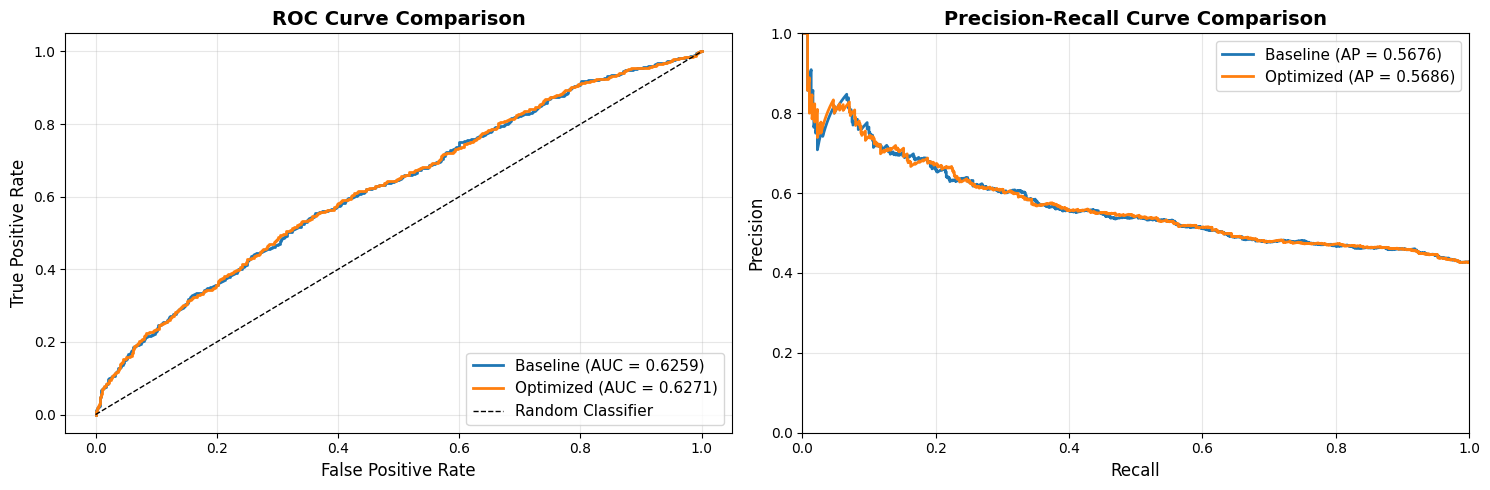


ROC-AUC Scores:
  Baseline Model:  0.6259
  Optimized Model: 0.6271
  Improvement:     +0.0012

Average Precision Scores:
  Baseline Model:  0.5676
  Optimized Model: 0.5686
  Improvement:     +0.0010


In [399]:
# 5. ROC AND PRECISION-RECALL CURVES
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

print("\n" + "="*70)
print("5. ROC AND PRECISION-RECALL CURVES")
print("="*70)

# Use saved baseline predictions
# ROC Curve
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, baseline_y_pred_proba)
roc_auc_baseline = auc(fpr_baseline, tpr_baseline)

fpr_optimized, tpr_optimized, _ = roc_curve(y_test, y_pred_proba_optimized)
roc_auc_optimized = auc(fpr_optimized, tpr_optimized)

# Precision-Recall Curve
precision_baseline, recall_baseline, _ = precision_recall_curve(y_test, baseline_y_pred_proba)
ap_baseline = average_precision_score(y_test, baseline_y_pred_proba)

precision_optimized, recall_optimized, _ = precision_recall_curve(y_test, y_pred_proba_optimized)
ap_optimized = average_precision_score(y_test, y_pred_proba_optimized)

# Plot 1: ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC Curve
axes[0].plot(fpr_baseline, tpr_baseline, label=f'Baseline (AUC = {roc_auc_baseline:.4f})', linewidth=2)
axes[0].plot(fpr_optimized, tpr_optimized, label=f'Optimized (AUC = {roc_auc_optimized:.4f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall_baseline, precision_baseline, label=f'Baseline (AP = {ap_baseline:.4f})', linewidth=2)
axes[1].plot(recall_optimized, precision_optimized, label=f'Optimized (AP = {ap_optimized:.4f})', linewidth=2)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nROC-AUC Scores:")
print(f"  Baseline Model:  {roc_auc_baseline:.4f}")
print(f"  Optimized Model: {roc_auc_optimized:.4f}")
print(f"  Improvement:     {roc_auc_optimized - roc_auc_baseline:+.4f}")

print(f"\nAverage Precision Scores:")
print(f"  Baseline Model:  {ap_baseline:.4f}")
print(f"  Optimized Model: {ap_optimized:.4f}")
print(f"  Improvement:     {ap_optimized - ap_baseline:+.4f}")

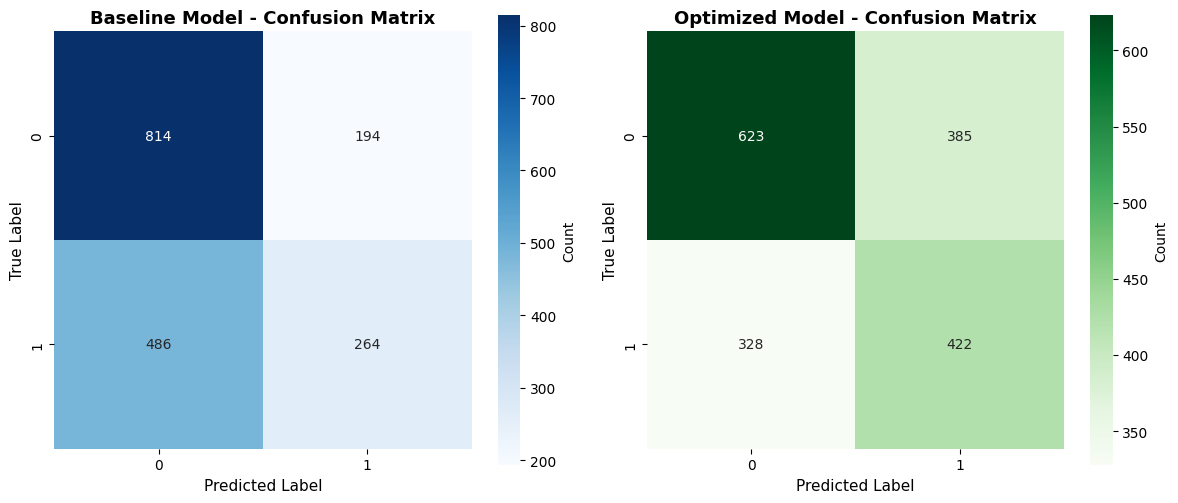


Confusion Matrix Analysis:
  Baseline - TN: 814, FP: 194, FN: 486, TP: 264
  Optimized - TN: 623, FP: 385, FN: 328, TP: 422


In [400]:
# 6. CONFUSION MATRIX COMPARISON
# Use saved baseline predictions
cm_baseline = confusion_matrix(y_test, baseline_y_pred)
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline Confusion Matrix
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'}, square=True)
axes[0].set_title('Baseline Model - Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Optimized Confusion Matrix
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            cbar_kws={'label': 'Count'}, square=True)
axes[1].set_title('Optimized Model - Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

print("\nConfusion Matrix Analysis:")
print(f"  Baseline - TN: {cm_baseline[0,0]}, FP: {cm_baseline[0,1]}, FN: {cm_baseline[1,0]}, TP: {cm_baseline[1,1]}")
print(f"  Optimized - TN: {cm_optimized[0,0]}, FP: {cm_optimized[0,1]}, FN: {cm_optimized[1,0]}, TP: {cm_optimized[1,1]}")


7. FEATURE IMPORTANCE (OPTIMIZED MODEL COEFFICIENTS)

Feature Importance (sorted by absolute coefficient value):
          Feature  Coefficient
           BPQ020     0.397528
fat_calorie_ratio     0.162770
         RIAGENDR     0.147457
   DBD900_missing    -0.138669
           SLD012    -0.090324
           PAQ620    -0.083392
   sodium_density     0.079825
         RIDAGEYR    -0.076631
         INDFMMPI    -0.075770
    protein_ratio    -0.038360
      sugar_ratio     0.016275
  fast_food_ratio     0.013490
           DBD895    -0.010834
           DBD900    -0.006406
 calorie_activity     0.000000


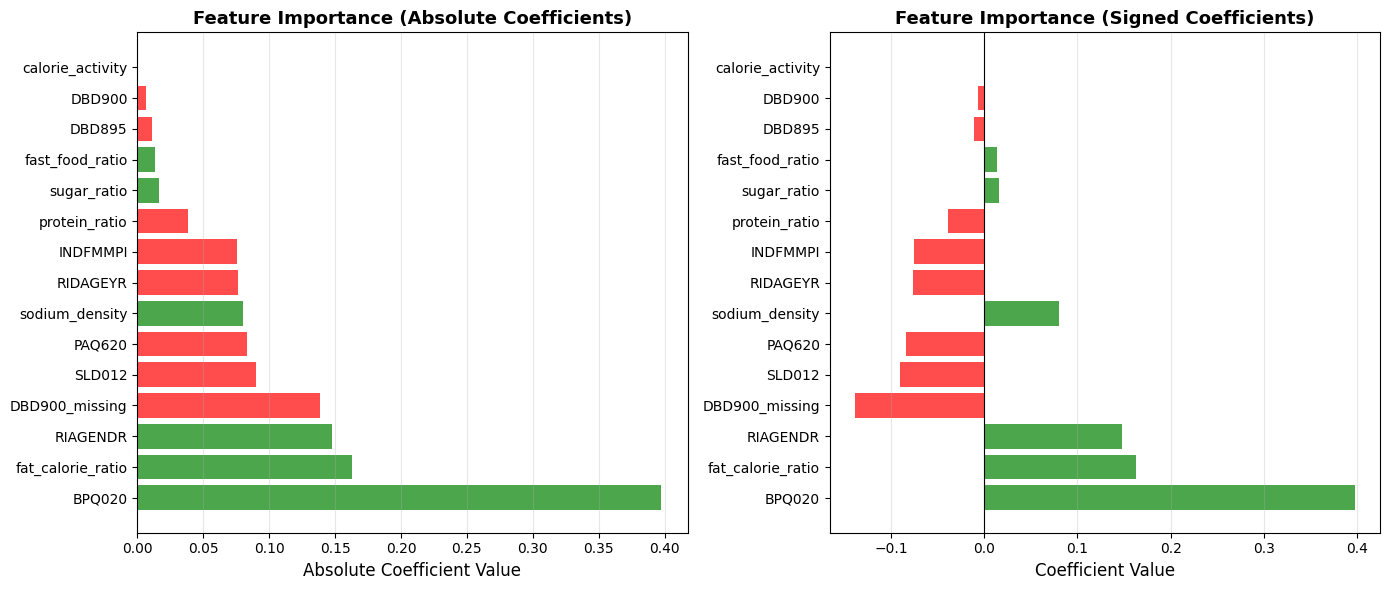


Coefficient Interpretation:
  Positive coefficient: Increases odds of obesity
  Negative coefficient: Decreases odds of obesity
  Model Intercept: -0.0155


In [401]:
# 7. FEATURE IMPORTANCE FROM OPTIMIZED MODEL
print("\n" + "="*70)
print("7. FEATURE IMPORTANCE (OPTIMIZED MODEL COEFFICIENTS)")
print("="*70)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': optimized_model.coef_[0],
    'Abs_Coefficient': np.abs(optimized_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("\nFeature Importance (sorted by absolute coefficient value):")
print(feature_importance[['Feature', 'Coefficient']].to_string(index=False))

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Absolute coefficients
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
axes[0].barh(feature_importance['Feature'], feature_importance['Abs_Coefficient'], color=colors, alpha=0.7)
axes[0].set_xlabel('Absolute Coefficient Value', fontsize=12)
axes[0].set_title('Feature Importance (Absolute Coefficients)', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Signed coefficients
colors_signed = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
axes[1].barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors_signed, alpha=0.7)
axes[1].set_xlabel('Coefficient Value', fontsize=12)
axes[1].set_title('Feature Importance (Signed Coefficients)', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCoefficient Interpretation:")
print("  Positive coefficient: Increases odds of obesity")
print("  Negative coefficient: Decreases odds of obesity")
print(f"  Model Intercept: {optimized_model.intercept_[0]:.4f}")

In [402]:
# 8. COMPREHENSIVE OPTIMIZATION REPORT
print("\n" + "="*70)
print("PHASE 1A: MODEL OPTIMIZATION REPORT")
print("="*70)

report = f"""
{'='*70}
CAPSTONE PROJECT - PHASE 1A MODEL OPTIMIZATION REPORT
{'='*70}

1. FEATURE ANALYSIS SUMMARY
{'-'*70}
Total Features: {X.shape[1]}
Training Samples: {X_train.shape[0]}
Test Samples: {X_test.shape[0]}

Multicollinearity Status:
{'-'*35}
"""

# Check VIF status
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    report += f"⚠ WARNING: {len(high_vif)} features with VIF > 10 (high multicollinearity)\n"
    for _, row in high_vif.iterrows():
        report += f"  - {row['Feature']}: VIF = {row['VIF']:.2f}\n"
else:
    report += "✓ Good: No features with VIF > 10\n"

moderate_vif = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]
if len(moderate_vif) > 0:
    report += f"\n⚠ Note: {len(moderate_vif)} features with VIF 5-10 (moderate multicollinearity)\n"
    for _, row in moderate_vif.iterrows():
        report += f"  - {row['Feature']}: VIF = {row['VIF']:.2f}\n"

if len(highly_correlated_pairs) > 0:
    report += f"\n⚠ Highly Correlated Pairs (|r| > 0.7): {len(highly_correlated_pairs)}\n"
    for pair in highly_correlated_pairs:
        report += f"  - {pair[0]} <-> {pair[1]}: r = {pair[2]:.4f}\n"
else:
    report += "\n✓ No highly correlated feature pairs (|r| > 0.7)\n"

report += f"""

2. HYPERPARAMETER TUNING RESULTS
{'-'*70}
Grid Search Configuration:
  - Parameter combinations tested: {total_combinations}
  - Cross-validation folds: 5
  - Scoring metric: ROC-AUC

Best Parameters Found:
  - C (Regularization): {grid_search.best_params_['C']}
  - Solver: {grid_search.best_params_['solver']}
  - L1 Ratio: {grid_search.best_params_['l1_ratio']}
  - Max Iterations: {grid_search.best_params_['max_iter']}
  - Class Weight: {grid_search.best_params_['class_weight']}

Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}

3. MODEL PERFORMANCE COMPARISON
{'-'*70}
                        Baseline Model    Optimized Model    Improvement
Accuracy               {baseline_metrics['Accuracy']:>18.4f}    {optimized_metrics['Accuracy']:>18.4f}    {comparison_df.loc['Accuracy', 'Improvement']:>+10.4f}
Precision              {baseline_metrics['Precision']:>18.4f}    {optimized_metrics['Precision']:>18.4f}    {comparison_df.loc['Precision', 'Improvement']:>+10.4f}
Recall                 {baseline_metrics['Recall']:>18.4f}    {optimized_metrics['Recall']:>18.4f}    {comparison_df.loc['Recall', 'Improvement']:>+10.4f}
F1-Score               {baseline_metrics['F1-Score']:>18.4f}    {optimized_metrics['F1-Score']:>18.4f}    {comparison_df.loc['F1-Score', 'Improvement']:>+10.4f}
ROC-AUC                {baseline_metrics['ROC-AUC']:>18.4f}    {optimized_metrics['ROC-AUC']:>18.4f}    {comparison_df.loc['ROC-AUC', 'Improvement']:>+10.4f}

4. CONFUSION MATRIX (OPTIMIZED MODEL)
{'-'*70}
                Predicted No    Predicted Yes
Actual No       {cm_optimized[0,0]:>15}    {cm_optimized[0,1]:>15}
Actual Yes      {cm_optimized[1,0]:>15}    {cm_optimized[1,1]:>15}

5. TOP 3 MOST IMPORTANT FEATURES
{'-'*70}
"""

for i, (_, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    direction = "↑ increases" if row['Coefficient'] > 0 else "↓ decreases"
    report += f"{i}. {row['Feature']:15} (coef: {row['Coefficient']:>7.4f}) - {direction} obesity odds\n"

report += f"""

6. KEY FINDINGS & RECOMMENDATIONS
{'-'*70}
"""

# Findings
improvement_pct = ((optimized_metrics['ROC-AUC'] - baseline_metrics['ROC-AUC']) / baseline_metrics['ROC-AUC'] * 100)
report += f"✓ Model optimization achieved {improvement_pct:.1f}% improvement in ROC-AUC\n"

if optimized_metrics['Recall'] > baseline_metrics['Recall']:
    recall_improvement = ((optimized_metrics['Recall'] - baseline_metrics['Recall']) / baseline_metrics['Recall'] * 100)
    report += f"✓ Recall improved by {recall_improvement:.1f}%, better at identifying positive cases\n"

if optimized_metrics['Precision'] > baseline_metrics['Precision']:
    prec_improvement = ((optimized_metrics['Precision'] - baseline_metrics['Precision']) / baseline_metrics['Precision'] * 100)
    report += f"✓ Precision improved by {prec_improvement:.1f}%, fewer false positives\n"

if len(high_vif) > 0:
    report += f"⚠ Consider addressing multicollinearity - {len(high_vif)} features have VIF > 10\n"

report += "\nRecommendations:\n"
report += "  1. Deploy optimized model with tuned hyperparameters\n"
report += "  2. Monitor model performance on new data\n"
report += "  3. Consider feature engineering if multicollinearity persists\n"
report += "  4. Implement regular retraining schedule (quarterly recommended)\n"

report += f"""

{'='*70}
Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*70}
"""

print(report)

# Save report to memory for reference
optimization_report = report


PHASE 1A: MODEL OPTIMIZATION REPORT

CAPSTONE PROJECT - PHASE 1A MODEL OPTIMIZATION REPORT

1. FEATURE ANALYSIS SUMMARY
----------------------------------------------------------------------
Total Features: 15
Training Samples: 7032
Test Samples: 1758

Multicollinearity Status:
-----------------------------------
⚠ WARNING: 3 features with VIF > 10 (high multicollinearity)
  - SLD012: VIF = 14.83
  - fat_calorie_ratio: VIF = 11.62
  - RIDAGEYR: VIF = 10.00

⚠ Note: 2 features with VIF 5-10 (moderate multicollinearity)
  - PAQ620: VIF = 9.48
  - protein_ratio: VIF = 9.11

⚠ Highly Correlated Pairs (|r| > 0.7): 1
  - DBD900 <-> fast_food_ratio: r = 0.8767


2. HYPERPARAMETER TUNING RESULTS
----------------------------------------------------------------------
Grid Search Configuration:
  - Parameter combinations tested: 30
  - Cross-validation folds: 5
  - Scoring metric: ROC-AUC

Best Parameters Found:
  - C (Regularization): 0.1
  - Solver: saga
  - L1 Ratio: 1
  - Max Iterations: 200

In [403]:
# 9. SAVE OPTIMIZATION REPORT TO FILE
import os
from pathlib import Path

# Create output directory if it doesn't exist
report_dir = Path('./additional')
report_dir.mkdir(exist_ok=True)

# Save comprehensive report
report_file = report_dir / 'optimization_report.txt'
with open(report_file, 'w') as f:
    f.write(optimization_report)

print(f"✓ Full optimization report saved to: {report_file}")

# Save detailed metrics to CSV
metrics_file = report_dir / 'model_metrics_comparison.csv'
comparison_df.to_csv(metrics_file)
print(f"✓ Metrics comparison saved to: {metrics_file}")

# Save feature importance to CSV
feature_importance_file = report_dir / 'feature_importance_optimized.csv'
feature_importance.to_csv(feature_importance_file, index=False)
print(f"✓ Feature importance saved to: {feature_importance_file}")

# Save VIF analysis to CSV
vif_file = report_dir / 'vif_analysis.csv'
vif_data.to_csv(vif_file, index=False)
print(f"✓ VIF analysis saved to: {vif_file}")

# Save best parameters to file
best_params_file = report_dir / 'best_hyperparameters.txt'
with open(best_params_file, 'w') as f:
    f.write("Best Hyperparameters from Grid Search\n")
    f.write("="*50 + "\n\n")
    for param, value in grid_search.best_params_.items():
        f.write(f"{param}: {value}\n")
    f.write(f"\nCross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}\n")

print(f"✓ Best hyperparameters saved to: {best_params_file}")
print(f"\n{'='*70}")
print("ALL PHASE 1A OPTIMIZATION OUTPUTS SAVED")
print(f"{'='*70}")

✓ Full optimization report saved to: additional/optimization_report.txt
✓ Metrics comparison saved to: additional/model_metrics_comparison.csv
✓ Feature importance saved to: additional/feature_importance_optimized.csv
✓ VIF analysis saved to: additional/vif_analysis.csv
✓ Best hyperparameters saved to: additional/best_hyperparameters.txt

ALL PHASE 1A OPTIMIZATION OUTPUTS SAVED
